In [7]:
import yfinance as yf

stocks = ["AAPL", "MSFT", "NVDA"]
data = yf.download(stocks,
                   start = "2026-06-16",
                   auto_adjust = True
                   )["Close"]

print(data.head(100))

[*********************100%***********************]  3 of 3 completed

Ticker            AAPL        MSFT        NVDA
Date                                          
2026-06-16  298.982147  393.829987  207.410004
2026-06-17  295.694977  378.910004  204.649994
2026-06-18  297.753204  379.399994  210.690002
2026-06-22  296.754089  367.339996  208.649994
2026-06-23  294.046387  373.940002  200.039993
2026-06-24  292.827423  365.459991  199.000000
2026-06-25  274.912903  352.829987  195.740005
2026-06-26  283.535461  372.970001  192.529999
2026-06-29  281.497223  368.570007  194.970001
2026-06-30  289.110657  373.019989  200.089996
2026-07-01  294.126343  384.279999  197.580002
2026-07-02  308.364044  390.489990  194.830002
2026-07-06  312.390594  386.739990  195.550003
2026-07-07  310.392303  388.839996  196.929993
2026-07-08  313.119965  383.339996  204.119995
2026-07-09  315.947510  384.359985  202.779999
2026-07-10  315.048309  385.100006  210.960007
2026-07-13  317.036560  390.989990  203.529999
2026-07-14  314.588684  384.929993  211.800003
2026-07-15  3

In [8]:
type(data)

pandas.DataFrame

In [2]:
# Calculate the returns 
import numpy as np
import pandas as pd

#log returns
log_returns = np.log(data/data.shift(1))
log_returns = log_returns.dropna()

#simple returns
simple_returns = (data - data.shift(1))/data.shift(1)
simple_returns = simple_returns.dropna()

#concatenate the two returns
returns = pd.concat([simple_returns, log_returns], 
                    axis=1, 
                    keys=["Simple Returns","Log Returns"]
                    )

print(returns)

           Simple Returns                     Log Returns                    
Ticker               AAPL      MSFT      NVDA        AAPL      MSFT      NVDA
Date                                                                         
2026-01-05      -0.013837 -0.000190 -0.003866   -0.013934 -0.000190 -0.003873
2026-01-06      -0.018334  0.011970 -0.004678   -0.018504  0.011899 -0.004689
2026-01-07      -0.007737  0.010365  0.009987   -0.007768  0.010312  0.009938
2026-01-08      -0.004955 -0.011087 -0.021522   -0.004968 -0.011148 -0.021757
2026-01-09       0.001274  0.002447 -0.000973    0.001273  0.002444 -0.000973
...                   ...       ...       ...         ...       ...       ...
2026-07-06       0.013058 -0.009603  0.003696    0.012973 -0.009650  0.003689
2026-07-07      -0.006397  0.005430  0.007057   -0.006417  0.005415  0.007032
2026-07-08       0.008788 -0.014145  0.036510    0.008749 -0.014246  0.035860
2026-07-09       0.009030  0.002661 -0.006565    0.008990  0.002

<Axes: >

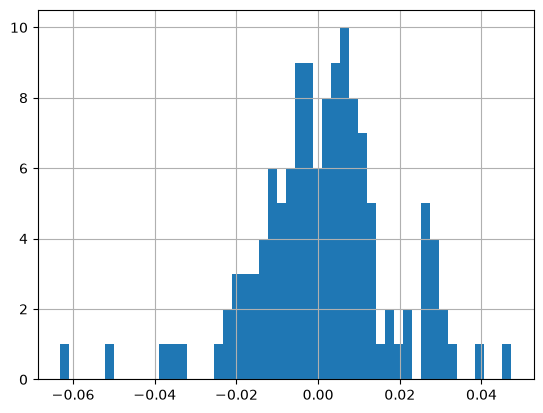

In [3]:
import matplotlib.pyplot as plt

log_returns["AAPL"].hist(bins=50)

<Axes: >

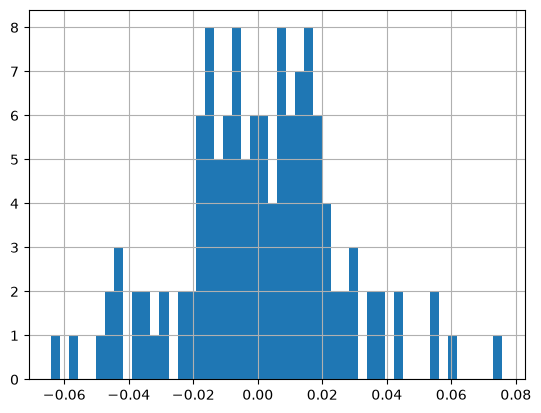

In [4]:
log_returns["NVDA"].hist(bins=50)

<Axes: >

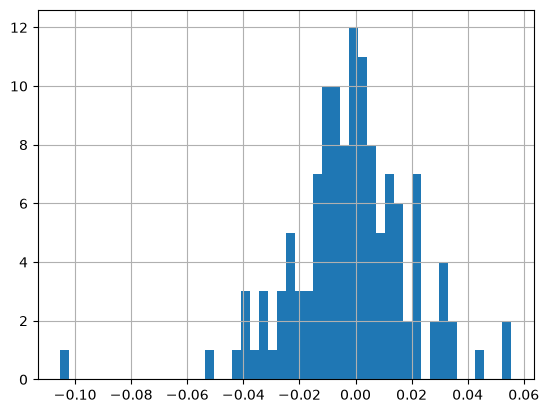

In [5]:
log_returns["MSFT"].hist(bins=50)

In [13]:
# Starting with the simulation of one stock
mu = log_returns["AAPL"].mean()*252
sigma = log_returns["AAPL"].std()*(252**0.5)

S0 = log_returns["AAPL"].iloc[-1]
T = 252
t = 1/252

plot = [S0]
for i in range(T):
    z = np.random.normal()
    
    next_price = plot[-1]*np.exp(       ## Geometric Brownian Motion (GBM) in action
        (mu - sigma**2/2)*t + 
        sigma*np.sqrt(t)*z)
    
    plot.append(next_price)

Text(0.5, 1.0, 'Simulated AAPL stock')

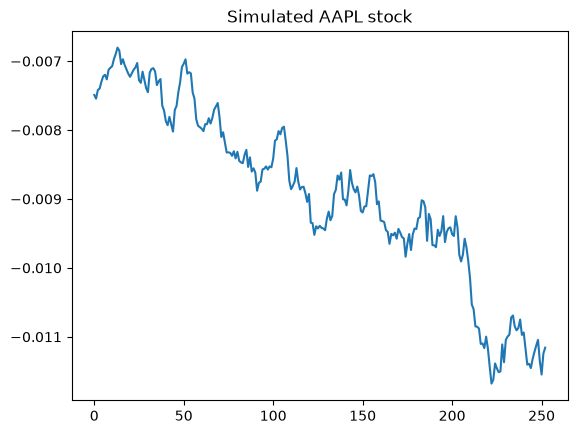

In [14]:
plt.plot(plot)
plt.title("Simulated AAPL stock")

In [16]:
# Simulating 1000 Paths of AAPL stock
n_sims = 1000
paths = np.zeros((T, n_sims))
paths[0] = S0

for sim in range(n_sims):
    for time in range(1, T):
        
        z = np.random.normal()
    
        paths[time, sim] = paths[time-1, sim]*np.exp(       ## Geometric Brownian Motion (GBM) in action
                    (mu - sigma**2/2)*t + 
                    sigma*np.sqrt(t)*z
                    )

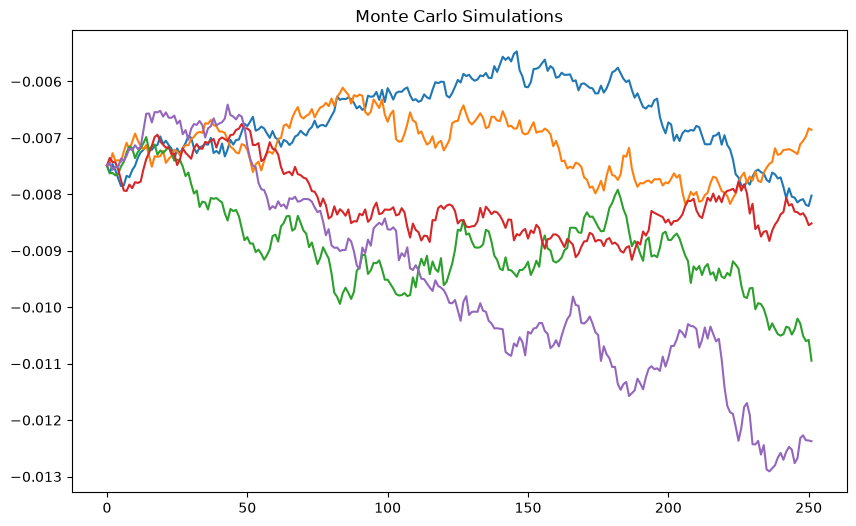

In [18]:
plt.figure(figsize=(10,6))

plt.plot(paths[:,0:5])

plt.title("Monte Carlo Simulations")
plt.show()

In [36]:
# Portfolio Simulation
weights = np.array([0.5, 0.3, 0.2])

cov_matrix = log_returns.cov()*252
mean_returns = log_returns.mean()*252

portfolio_returns = np.dot(weights, mean_returns)      #Portfolio returns = (Weights)^T * mean_returns
volatility = np.sqrt(np.dot(weights, np.dot(cov_matrix, weights)))  #Portfolio volatility = sqrt((Weights)^T * Covariance Matrix * Weights)

In [37]:
portfolio_returns

np.float64(0.05716435889543813)